In [4]:
import mediapipe as mp
import cv2 as cv
import numpy as np
from scipy.signal import butter

LANDMARKS = 33
KERNEL_SIZE = 5
CUTOFF_FREQ = 6.0

model_path = "./pose_landmarker_full.task"

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
draw_landmarks = mp.tasks.vision.drawing_utils.draw_landmarks
POSE_LANDMARKS = mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS
NormalizedLandmark = mp.tasks.components.containers.NormalizedLandmark

In [5]:
class LandmarkMedianFilter:
    def __init__(self, num_landmarks, kernel_size, dims=3):
        """
        landmarks: Total human pose landmarks count
        kernel_size: Size of median filter kernel
        """
        self.num_landmarks = num_landmarks
        if kernel_size%2 == 0:
            raise ValueError("Argument 'kernel_size' have to be an odd number")
        self.kernel_size = kernel_size
        self.kernel = np.full((num_landmarks, dims, kernel_size), np.nan)
        self.idx = 0
    def filter(self, landmarks):
        self.kernel[:,:,self.idx] = landmarks
        self.idx = (self.idx + 1) % self.kernel_size
        filtered = np.nanmedian(self.kernel, axis=2)
        return filtered

In [6]:
class LandmarkButterworthFilter:
    def __init__(self, cutoff_freq, sample_rate, order=2):
        self.cutoff_freq = cutoff_freq
        self.sr = sample_rate
        self.order = order
        self.b, self.a = butter(order, cutoff_freq/(sample_rate*0.5), btype='low', analog=False)
        self.z = None
    def filter(self, landmarks):
        if self.z is None:
            self.z = np.zeros(max(len(self.a), len(self.b)) - 1)
        
        a = self.a
        b = self.b

        y = b[0] * landmarks + self.z[0]

        self.z[0] = b[1] * landmarks - a[1] * y + self.z[1]
        if len(self.z) > 1:
            self.z[1] = b[2] * landmarks - a[2] * y

        return y

In [7]:
class LandmarkInterpolation:
    def __init__(self, num_landmarks, ):
        self.num_landmarks = num_landmarks

        self.low_vision = [0] * num_landmarks
    def update(self, landmarks, visibilities):
        for i in range(self.num_landmarks):
            if visibilities[i] >= self.threshhold:
                self.low_vision[i] = 0
                continue
            self.low_vision[i] += 1
            if self.low_vision[i] > self.max_frames:
                continue

In [8]:
class FilterPipeline:
    def __init__(self, num_landmarks, kernel_size, fps, cutoff_freq, dims=3):
        self.num_landmarks = num_landmarks
        self.kernel_size = kernel_size
        self.dims = dims

        self.low_vision = [0] * num_landmarks

        self.median_filter = LandmarkMedianFilter(num_landmarks, kernel_size, dims)
        self.butter_filters = np.array([
            [LandmarkButterworthFilter(cutoff_freq, fps) for _ in range(dims)] 
            for _ in range(num_landmarks)
        ])
    def update(self, raw_landmarks):
        landmark_array = [[landmark.x, landmark.y, landmark.z] for landmark in raw_landmarks]
        visibility_array = [landmark.visibility for landmark in raw_landmarks]

        median_filtered = self.median_filter.filter(landmark_array)

        filtered = np.zeros_like(median_filtered)
        for i in range(self.num_landmarks):
            for j in range(self.dims):
                if not np.isnan(median_filtered[i, j]):
                    filtered[i, j] = self.butter_filters[i, j].filter(median_filtered[i, j])
                else:
                    filtered[i, j] = median_filtered[i, j]

        filtered_landmarks = [NormalizedLandmark(coord[0], coord[1], coord[2]) for coord in filtered]
        return filtered_landmarks

In [9]:
def scalar_power_3d(a, b):
    return a[0]*b[0] + a[1]*b[1] + a[2]*b[2]
def v_abs_3d(a):
    return np.sqrt(a[0]*a[0] + a[1]*a[1] + a[2]*a[2])
def get_vector_3d(landmark1: NormalizedLandmark, landmark2: NormalizedLandmark):
    return [landmark1.x - landmark2.x, landmark1.y - landmark2.y, landmark1.z - landmark2.z]

def scalar_power_2d(a, b):
    return a[0]*b[0] + a[1]*b[1]
def v_abs_2d(a):
    return np.sqrt(a[0]*a[0] + a[1]*a[1])
def get_vector_2d(landmark1: NormalizedLandmark, landmark2: NormalizedLandmark):
    return [landmark1.x - landmark2.x, landmark1.y - landmark2.y]

def get_mediapipe_angles_3d(landmarks):
    v_r_torso = get_vector_3d(landmarks[24], landmarks[12])
    v_r_thigh = get_vector_3d(landmarks[26], landmarks[24])
    v_r_shank = get_vector_3d(landmarks[28], landmarks[26])
    v_r_foot = get_vector_3d(landmarks[32], landmarks[30])

    v_l_torso = get_vector_3d(landmarks[23], landmarks[11])
    v_l_thigh = get_vector_3d(landmarks[25], landmarks[23])
    v_l_shank = get_vector_3d(landmarks[27], landmarks[25])
    v_l_foot = get_vector_3d(landmarks[31], landmarks[29])

    r_hip_angle = np.arccos((scalar_power_3d(v_r_torso, v_r_thigh))/(v_abs_3d(v_r_torso)*v_abs_3d(v_r_thigh)))
    r_knee_angle = np.arccos((scalar_power_3d(v_r_thigh, v_r_shank))/(v_abs_3d(v_r_thigh)*v_abs_3d(v_r_shank)))
    r_ankle_angle = np.arccos((scalar_power_3d(v_r_shank, v_r_foot))/(v_abs_3d(v_r_shank)*v_abs_3d(v_r_foot)))

    l_hip_angle = np.arccos((scalar_power_3d(v_l_torso, v_l_thigh))/(v_abs_3d(v_l_torso)*v_abs_3d(v_l_thigh)))
    l_knee_angle = np.arccos((scalar_power_3d(v_l_thigh, v_l_shank))/(v_abs_3d(v_l_thigh)*v_abs_3d(v_l_shank)))
    l_ankle_angle = np.arccos((scalar_power_3d(v_l_shank, v_l_foot))/(v_abs_3d(v_l_shank)*v_abs_3d(v_l_foot)))
    return [
        (23, np.rad2deg(l_hip_angle)),
        (24, np.rad2deg(r_hip_angle)),
        (25, np.rad2deg(l_knee_angle)),
        (26, np.rad2deg(r_knee_angle)),
        (27, np.rad2deg(r_ankle_angle)),
        (28, np.rad2deg(l_ankle_angle)),
    ]

def get_mediapipe_angles_2d(landmarks):
    v_r_torso = get_vector_2d(landmarks[24], landmarks[12])
    v_r_thigh = get_vector_2d(landmarks[26], landmarks[24])
    v_r_shank = get_vector_2d(landmarks[28], landmarks[26])
    v_r_foot = get_vector_2d(landmarks[32], landmarks[30])

    v_l_torso = get_vector_2d(landmarks[23], landmarks[11])
    v_l_thigh = get_vector_2d(landmarks[25], landmarks[23])
    v_l_shank = get_vector_2d(landmarks[27], landmarks[25])
    v_l_foot = get_vector_2d(landmarks[31], landmarks[29])

    r_hip_angle = np.arccos((scalar_power_2d(v_r_torso, v_r_thigh))/(v_abs_2d(v_r_torso)*v_abs_2d(v_r_thigh)))
    r_knee_angle = np.arccos((scalar_power_2d(v_r_thigh, v_r_shank))/(v_abs_2d(v_r_thigh)*v_abs_2d(v_r_shank)))
    r_ankle_angle = np.arccos((scalar_power_2d(v_r_shank, v_r_foot))/(v_abs_2d(v_r_shank)*v_abs_2d(v_r_foot)))

    l_hip_angle = np.arccos((scalar_power_2d(v_l_torso, v_l_thigh))/(v_abs_2d(v_l_torso)*v_abs_2d(v_l_thigh)))
    l_knee_angle = np.arccos((scalar_power_2d(v_l_thigh, v_l_shank))/(v_abs_2d(v_l_thigh)*v_abs_2d(v_l_shank)))
    l_ankle_angle = np.arccos((scalar_power_2d(v_l_shank, v_l_foot))/(v_abs_2d(v_l_shank)*v_abs_2d(v_l_foot)))
    return [
        (23, np.rad2deg(l_hip_angle)),
        (24, np.rad2deg(r_hip_angle)),
        (25, np.rad2deg(l_knee_angle)),
        (26, np.rad2deg(r_knee_angle)),
        (27, np.rad2deg(r_ankle_angle)),
        (28, np.rad2deg(l_ankle_angle)),
    ]

In [10]:
def get_angles_params(angles_buffer, ft_ms):
    angle_params = []
    dt = ft_ms*2
    for i in range(len(angles_buffer[0])):
        angle_params.append(((angles_buffer[2][i][1] - angles_buffer[0][i][1])/dt, (angles_buffer[2][i][1] - 2*angles_buffer[1][i][1] + angles_buffer[0][i][1])/((dt*dt)/4)))
    return angle_params

In [11]:
def draw_angles(frame, landmarks, angles, resolution):
    for i, angle in angles:
        land = landmarks[i]
        ang_str = "%.2f°" % angle
        cv.putText(frame, ang_str, (int(land.x*resolution[0]), int(land.y*resolution[1])), cv.FONT_ITALIC, 1, (0,255,0), 2, cv.LINE_AA)
def draw_speed(frame, speed_params):
    parts = ["Left hip: ", "Right hip: ", "Left knee: ", "Right knee: ", "Left ankle: ", "Right ankle: "]
    for idx, (speed, _) in enumerate(speed_params):
        cv.putText(frame, parts[idx] + "%.2f" % speed, (10, 25*(idx+1)), cv.FONT_ITALIC, 1, (0,0,0), 2, cv.LINE_AA)

In [ ]:
cap = cv.VideoCapture('./video.mp4')
framerate = int(cap.get(cv.CAP_PROP_FPS))
resolution = (int(cap.get(cv.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv.CAP_PROP_FRAME_HEIGHT)))
font = cv.FONT_HERSHEY_SIMPLEX

filter_pipeline = FilterPipeline(LANDMARKS, KERNEL_SIZE, int(cap.get(cv.CAP_PROP_FPS)), CUTOFF_FREQ)

fourcc = cv.VideoWriter_fourcc(*"XVID")
out = cv.VideoWriter('output1.avi', fourcc, 25.0, resolution)

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO
)

i = 0
landmarker = PoseLandmarker.create_from_options(options)

with PoseLandmarker.create_from_options(options) as landmarker:
    angles_buffer = []
    for True:
        ret, frame = cap.read()
        if not ret:
            break
            cap = cv.VideoCapture('./video.mp4')
            ret, frame = cap.read()
        
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        pose_landmarks = landmarker.detect_for_video(mp_image, i).pose_landmarks
        filtered_landmarks = None
        if len(pose_landmarks) > 0:
            filtered_landmarks = filter_pipeline.update(pose_landmarks[0])
            
            draw_landmarks(frame, filtered_landmarks, POSE_LANDMARKS)
            angles = get_mediapipe_angles_3d(filtered_landmarks)
            angles_buffer.append(angles)
            speed_params = None
            if len(angles_buffer) > 3:
                angles_buffer.pop(0)
                speed_params = get_angles_params(angles_buffer, frametime_ms)
            draw_angles(frame, filtered_landmarks, angles, resolution)
            if speed_params:
                draw_speed(frame, speed_params)

        cv.imshow("Video", frame)
        out.write(frame)
        i += frametime_ms

        if cv.waitKey(1) & 0xFF == ord('q'):
            break
cap.release()
cv.destroyAllWindows()

I0000 00:00:1775283818.308723    5314 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775283818.311853    5337 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.3-arch1.1), renderer: AMD Radeon RX 6700 XT (radeonsi, navi22, ACO, DRM 3.64, 6.19.9-arch1-1)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775283818.353642    5326 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775283818.368982    5323 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/sparkerxof/Диплом/.venv/lib/python3.14/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/sparkerxof/Диплом/.venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer

In [145]:
cap = cv.VideoCapture('./video.mp4')
frametime_ms = int((1/cap.get(cv.CAP_PROP_FPS))*1000)
#resolution = (int(cap.get(cv.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv.CAP_PROP_FRAME_HEIGHT)))
#font = cv.FONT_HERSHEY_SIMPLEX

#filter_pipeline = FilterPipeline(LANDMARKS, KERNEL_SIZE, int(cap.get(cv.CAP_PROP_FPS)), CUTOFF_FREQ)

fourcc = cv.VideoWriter_fourcc(*"XVID")
out = cv.VideoWriter('output1.avi', fourcc, 25.0, resolution)

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO
)

i = 0
with PoseLandmarker.create_from_options(options) as landmarker:
    angles_buffer = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            cap = cv.VideoCapture('./video.mp4')
            ret, frame = cap.read()
        
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        pose_landmarks = landmarker.detect_for_video(mp_image, i).pose_landmarks
        filtered_landmarks = None
        if len(pose_landmarks) > 0:
            filtered_landmarks = filter_pipeline.update(pose_landmarks[0])
            
            draw_landmarks(frame, filtered_landmarks, POSE_LANDMARKS)
            #angles = get_mediapipe_angles_3d(filtered_landmarks)
            #angles_buffer.append(angles)
            #speed_params = None
            if len(angles_buffer) > 3:
                angles_buffer.pop(0)
                speed_params = get_angles_params(angles_buffer, frametime_ms)
            #draw_angles(frame, filtered_landmarks, angles, resolution)
            #if speed_params:
                #draw_speed(frame, speed_params)

        cv.imshow("Video", frame)
        out.write(frame)
        i += frametime_ms

        if cv.waitKey(1) & 0xFF == ord('q'):
            break
cap.release()
cv.destroyAllWindows()

I0000 00:00:1775265580.756116  194235 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775265580.757472  194251 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.3-arch1.1), renderer: AMD Radeon RX 6700 XT (radeonsi, navi22, ACO, DRM 3.64, 6.19.9-arch1-1)
W0000 00:00:1775265580.789336  194244 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775265580.798803  194239 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (-0.750000), must be greater than 0
QFont::setPointSizeF: Point size <= 0 (

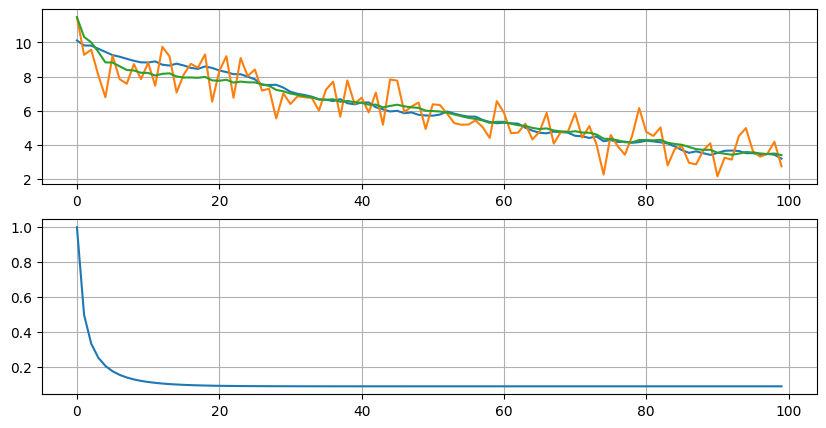

In [17]:
import numpy as np
import matplotlib.pyplot as plt
 
N = 100         # число наблюдений
dNoise = 1      # дисперсия шума
dSignal = 5     # дисперсия сигнала
r = 0.99        # коэффициент корреляции в модели движения
en = 0.1        # дисперсия СВ в модели движения
 
x = np.zeros(N)                         # истинные координаты перемещения (пока просто нули)
x[0] = np.random.normal(0, dSignal)     # формирование первой координаты
for i in range(1, N):                   # формирование последующих координат по модели АР
    x[i] = r*x[i-1] + np.random.normal(0, en)
 
z = x + np.random.normal(0, dNoise, N)  # формирование наблюдений
 
 
# фильтрация сигнала с помощью фильтра Калмана
xx = np.zeros(N)    # вектор для хранения оценок перемещений
P = np.zeros(N)     # вектор для хранения дисперсий ошибок оценивания
xx[0] = z[0]        # первая оценка
P[0] = dNoise     # дисперсия первой оценки
 
# рекуррентное вычисление оценок по фильтру Калмана
for i in range(1, N):
    Pe = r*r*P[i-1]+en*en
    P[i] = (Pe*dNoise)/(Pe+dNoise)
    xx[i] = r*xx[i-1]+P[i]/dNoise*(z[i]-r*xx[i-1])
 
# отображение результатов 
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 5))

ax1.plot(x)
ax1.plot(z)
ax1.plot(xx)
ax1.grid(True)
 
ax2.plot(P)
ax2.grid(True)
plt.show()